# Ordinal Regression for activity data (Oct 2022 data)


In [1]:
import pathlib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.Seq
import Bio.SeqIO

import utils

In [2]:
data_dir = pathlib.Path("../data/scratch/Oct22")
figs_dir = pathlib.Path("../data/misc")

In [3]:
seqs = pd.read_csv("../data/sequences_Oct22.tsv", sep="\t")
seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [4]:
seqs_no_dups = seqs.drop_duplicates(["parent", "category", "ss_aa"], keep='first')
seqs_no_dups

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [5]:
final_seqs = seqs_no_dups[seqs_no_dups.ss_aa != "*0*" ]
final_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
6,"A328T,G774T",1200,2,2,"T110S,M258I",False,2,1VH,L
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


## create one-hot encoding of ss_aa

['A15S,F152L,N198K',
 'K227E',
 'P6R,S60G,G86D',
 'A24V,N189D',
 'T110S,M258I',
 'D36V',
 'S60G,H129Q',
 'F152C,E266K',
 'F150S',
 'C156S',
 'N65D,R163H,H172L,M193I,E201G',
 'M21V,S58G,Q80L',
 'G259C',
 'A25V',
 'H210Y',
 'D33E,D130G,L137V,M258I',
 'T22A,G98A',
 'T14A,D87G,R255C',
 'H67Y,M193T,D267E',
 'L230V',
 'G106D',
 'I42L',
 'A205V',
 'A15S,D49E,T110A,E215G',
 'P145S,V159A',
 'M10V,P61L',
 'S202N,I228V',
 'H68L,D164V,W196C,H246R',
 'H68R,Q233L',
 'R17C,R102C,V133A',
 'F12I,M229V',
 'T22A,G70C,G79C,D190G,E208G',
 'H172R',
 'N167S,E208G,Q233R',
 'I99T,M209V,E223A',
 'E47G,A73T,K92I,T110S,D158N',
 'A16S,D54E,V72A,T183A',
 'D31V,D118G',
 'F240Y',
 'R17C,E144G',
 'Q8L',
 'P145Q',
 'N65S,I248V',
 'E34A,I263V',
 'F146V',
 'V133A',
 'F57L,F146S',
 'K231R',
 'D49Y,F152I,W196C,A247V',
 'N65D',
 'V39I,K92R,H172Y',
 'S173G',
 'N198I',
 'T22S,F62L,G192C,S253G',
 'F62L,T74A',
 'K171E,D190N',
 'P61L,F150S',
 'T14A,K227R',
 'H20P,E47G,R214G',
 'M40T,T110I,A205V',
 'A32T,F116L',
 'G46S,L182P,D197

In [25]:
class MutationEncoder:

    def __init__(self):
        self.sorted_positions = None
        self.lookupd = {}
        self.num_categories_pos = None
        self.category_start_pos = None
        self.N_one_hot = 0
        
    
    def fit(self, mutation_list):
        all_mutations = [msplit for m in mutation_list for msplit in m.split(',')]
        all_mutations_pos = np.array([int(m[1:-1]) for m in all_mutations], dtype="int")
        all_mutations_char = np.array([m[-1] for m in all_mutations])
        all_mutations_wt = np.array(m[0] for m in all_mutations)
        
        self.sorted_positions = np.unique(all_mutations_pos)
        # create a lookup dictionary which has all the positions and the characters
        # at each position
        self.lookupd = {s:sorted(set(all_mutations_char[all_mutations_pos == s].tolist())) 
                        for s in self.sorted_positions}
        
        # count number of categories in each position
        self.num_categories_pos = [len(self.lookupd[s]) for s in self.sorted_positions]

        # total length of one_hot vector
        self.N_one_hot= sum(self.num_categories_pos)

        # cumulative sum of the number of categories
        self.category_start_pos = np.concatenate([[0], np.cumsum(self.num_categories_pos)[:-1]])
        
    def encode(self, prot):
        one_hot_prot = np.zeros(self.N_one_hot, dtype=float)
        if prot and prot != "*0*": 
            for m in prot.split(','):
                _, idx, mut = m[0], int(m[1:-1]), m[-1]
                # find out where this category starts in the one_hot index
                cs = self.category_start_pos[self.sorted_positions == idx]
                one_hot_prot[cs + self.lookupd[idx].index(mut)] = 1.
        return one_hot_prot

In [26]:
mutation_list = ['A15S,F152L,N198K',
 'K227E',
 'P6R,S60G,G86D']

In [27]:
enc = MutationEncoder()
enc.fit(mutation_list)

In [28]:
prot = 'P6R,K227E'
np.where(enc.encode(prot))[0]

array([0, 6])

In [29]:
np.where(enc.encode(''))[0]

array([], dtype=int64)

In [31]:
parent = "1VH"
mutation_list = final_seqs[final_seqs.parent == parent].ss_aa.to_list()
mutation_list
enc = MutationEncoder()
enc.fit(mutation_list)

x = final_seqs[final_seqs.parent == parent].ss_aa.map(enc.encode)

In [33]:
len(x[0])

604

In [ ]:
enc.fit(mut)

In [40]:
arr = [ ['.', '.', '.'], ['.', 'A', '.'], ['.', 'B', 'C'], ['.', 'C', 'D']]
arr

[['.', '.', '.'], ['.', 'A', '.'], ['.', 'B', 'C'], ['.', 'C', 'D']]

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [53]:
enc = OneHotEncoder(drop='first', sparse_output=False)

In [54]:
enc.fit(arr)

OneHotEncoder(drop='first', sparse_output=False)

In [55]:
enc.categories_

[array(['.'], dtype=object),
 array(['.', 'A', 'B', 'C'], dtype=object),
 array(['.', 'C', 'D'], dtype=object)]

In [56]:
enc.drop_idx_

array([0, 0, 0], dtype=object)

In [57]:
enc.transform(arr)

array([[0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1.]])

In [58]:
enc.get_feature_names_out()

array(['x1_A', 'x1_B', 'x1_C', 'x2_C', 'x2_D'], dtype=object)

In [4]:
df = pd.read_pickle(f"{bin_dir}/{activity_type}.pkl")
sample_info = pd.read_csv(f"{bin_dir}/sample_info.csv")

# mapping from bin_num to category
bin_category_dict = dict(zip(sample_info.bin_num, sample_info.category))

sample_info_activity = sample_info[
    sample_info.category.str.lower().str.contains(activity_type)]
# mapping from response to category
response_category_dict = dict(zip(sample_info_activity.response, 
                                 sample_info_activity.category))

print("Bin->Category mapping :\n    ", bin_category_dict)
print()
print("Response->Category mapping :\n    ", response_category_dict)
# from the previous directed evolution
# should we add 65 as well?
# NOTE: These are indexed with start codon = 1
beneficial_parent_indices = [71, 172, 152, 38, 233, 261, 48] 

Bin->Category mapping :
     {1: 'High Hydroxylation', 2: 'Parent Hydroxylation', 3: 'Low Hydroxylation', 4: 'No Hydroxylation', 5: 'High Azidation', 6: 'Parent Azidation', 7: 'Low Azidation', 8: 'No Azidation'}

Response->Category mapping :
     {3: 'High Azidation', 2: 'Parent Azidation', 1: 'Low Azidation', 0: 'No Azidation'}


In [5]:
print("\n>> Response Value Counts")
print(df.response.value_counts())
print(f"\n>> Number of sequences : {len(df)}")
N = len(df.iloc[0].sequence_aa)
print(f"\n>> Length of a sequence : {N}")
print(f"\n>> Number of unique sequences : {len(df.sequence_aa.unique())}")
df.head()


>> Response Value Counts
0    161
1     91
2     27
3     13
Name: response, dtype: int64

>> Number of sequences : 292

>> Length of a sequence : 274

>> Number of unique sequences : 276


,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_trunc,is_not_trunc,seq_type,response
2625,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6459,5,0.113280,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2626,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6401,5,0.112263,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2627,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,6222,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,wt_aa,3
2628,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5110,5,0.089621,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2629,5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5039,5,0.088376,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3


In [6]:
df["dist_wt"] = df.sequence_aa.map(lambda x: utils.hamming_dist(x, WT_full))

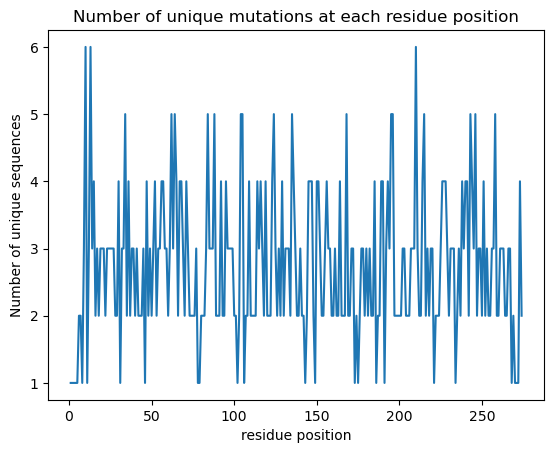

In [7]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence_aa.str.get(i).unique()) for i in range(N)])
plt.plot(np.arange(N) + 1, num_unique)
plt.title("Number of unique mutations at each residue position")
plt.xlabel("residue position")
plt.ylabel("Number of unique sequences");

In [8]:
# location of the first stop sequence
print(f">> Number of sequences with a stop before the end : {df.is_trunc.sum()}")

>> Number of sequences with a stop before the end : 21


In [9]:
df_nostop = df[~df.is_trunc].drop(columns=['is_trunc'])
print(f"Number of seqs={len(df_nostop)}, Number of unique aa seqs={len(df_nostop.sequence_aa.unique())}")
df_nostop.head()

Number of seqs=271, Number of unique aa seqs=255


,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_not_trunc,seq_type,response,dist_wt
2625,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6459,5,0.113280,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,3,1
2626,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6401,5,0.112263,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,3,2
2627,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,6222,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,3,0
2628,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5110,5,0.089621,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,3,2
2629,5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5039,5,0.088376,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,3,3


In [10]:
# Where is WildType in this dataframe
df_nostop[df_nostop.sequence_aa == WT_full]

,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_not_trunc,seq_type,response,dist_wt
2627,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,6222,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,3,0
2633,9,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2817,5,0.049405,True,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,3,0
2635,11,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2273,5,0.039865,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,3,0
3248,15,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2169,6,0.029591,True,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,2,0
3253,20,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,1481,6,0.020205,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,2,0
3257,24,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,1133,6,0.015457,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,2,0
4159,71,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,184,7,0.005829,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,1,0
4171,83,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,109,7,0.003453,True,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,1,0
4775,7,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,219,8,0.013466,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,0,0
4875,107,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,57,8,0.003505,True,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,0,0


In [11]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count_frac_bin', ascending=False).groupby('sequence_aa').head(1).reset_index(drop=True)
del df_unique["read_count"] # counts are not summed so drop it
df_unique.head()

,seq_idx,sequence,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_not_trunc,seq_type,response,dist_wt
0,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6,0.157574,False,MQHTYPAQLMRFGTAARAEHTTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,2,2
1,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5,0.113280,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,3,1
2,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5,0.112263,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,3,2
3,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,3,0
4,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5,0.089621,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,True,normal,3,2


In [12]:
# testing out how sensitive the model is by changing the response code of one mutant
# mut = list(str(WT_full))
# mut[152 - 1] = "L"
# mut = "".join(mut)
# df_unique.loc[df_unique.sequence_aa == mut, "bin_num"] = 5
# df_unique.loc[df_unique.sequence_aa == mut, "response"] = 3

In [13]:
# how many sequences do we have left?
len(df_unique)

255

In [14]:
# Where is WT in this dataframe
# It should be at the top
WT_in_df = df_unique[df_unique.sequence_aa==WT_full]
WT_in_df

,seq_idx,sequence,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_not_trunc,seq_type,response,dist_wt
3,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,True,wt_aa,3,0


In [15]:
if (WT_in_df.response.item() != 2):
    print(f"WT response code is {WT_in_df.response.item()}. It should be 2 (parent activity)")
    #print(f"******** Setting WT response code to 2 ********* (parent activity)")
    #df_unique.loc[df_unique.sequence_aa == WT_full, "response"] = 2

WT response code is 3. It should be 2 (parent activity)


In [16]:
df_model_seqs = df_unique[["sequence_aa", "bin_num", "count_frac_bin", 
                               "response", "dist_wt"]].rename(columns={"dist_wt":"dist_parent"})
# map bin_number to category
df_model_seqs["category"] = df_model_seqs.bin_num.map(bin_category_dict)

# Shorten sequences to just mutants
df_model_seqs["mutants_in_seq"] = df_model_seqs.sequence_aa.map(
        lambda x: utils.mut_as_string(x, WT_full, offset=1, mut_sep=";"))

# label mutants in beneficial residues
df_model_seqs["mut_type"] = ""
for m_idx in beneficial_parent_indices:
    m_idx = m_idx - 1 # convert to python indexing
    df_model_seqs.loc[df_model_seqs.sequence_aa.str.get(m_idx) != WT_full[m_idx],
                     "mut_type"] = "beneficial"

model_seqs_excel_filename = f"{output_dir}/{activity_type}_model_sequences.xlsx"
# save to Excel file
df_model_seqs.sort_values("response", ascending=False)[
        ["mutants_in_seq", "category", "count_frac_bin", 
         "mut_type", "response", "dist_parent"]
    ].style.format(
        formatter={'count_frac_bin': "{:.2%}"} # style is not saved for some reason
    ).hide_index().to_excel(model_seqs_excel_filename, sheet_name="model_input_seqs", 
                            index=False)

# save csv file but include aa sequence as well
df_model_seqs.sort_values("response", ascending=False)[
        ["mutants_in_seq", "category", "count_frac_bin", 
         "mut_type", "response", "dist_parent", "sequence_aa"]
        ].to_csv(f"{output_dir}/{activity_type}_model_sequences.csv",
                index=False)

/tmp/ipykernel_1496/627430997.py:19: FutureWarning: this method is deprecated in favour of `Styler.hide(axis="index")`
  df_model_seqs.sort_values("response", ascending=False)[


In [17]:
# Drop the Start and STOP Codons
df_unique.sequence_aa = df_unique.sequence_aa.str.slice(1, (len(WT_full)-1))
WT = WT_full[1:-1]
WT_str = str(WT)
N = len(WT_str)

## Ordinal regression

We are using the [mord package](https://github.com/fabianp/mord) to do ordinal regression. The steps in this section are 
1. Create design matrix and response vector
2. Run a cross validated search for the best regularization parameter
3. Save coefficients

In [18]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score


import mord
from mord import LogisticAT


import scipy.stats

In [19]:
y = df_unique.response.to_numpy()
design_cols = df_unique.sequence_aa.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now

X = enc.fit_transform(design_cols)
print(X.shape)
X

(255, 713)


/home/romeroroot/miniconda3/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:808: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[1., 1., 1., ..., 1., 0., 0.],
       [1., 1., 1., ..., 1., 0., 0.],
       [1., 1., 1., ..., 1., 0., 0.],
       ...,
       [1., 1., 1., ..., 1., 0., 0.],
       [1., 1., 1., ..., 1., 0., 0.],
       [1., 1., 1., ..., 1., 0., 0.]])

In [20]:
# Try out model with alpha = 1.0. This will get overwritten in the gridsearch
model = mord.LogisticAT(alpha=1.0)
#model = LogisticAT(alpha=1.0)

model.fit(X, y)

# The score is negative of mean absolute error between prediction and response vector
print(f"Model Score with alpha={model.alpha} : {model.score(X, y):.2f}")

Model Score with alpha=1.0 : -0.16


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

In [22]:
# Create pipeline with mord so that we are removing features that are all one
# Also we are standardizing features by their mean and standard deviation
pipeline = Pipeline([('vt', VarianceThreshold()), 
                     ('scaler', StandardScaler()), 
                     ('model', model)])

alphas = np.logspace(-6, 3, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=pipeline, param_grid=dict(model__alpha=alphas), 
                       cv=StratifiedKFold(5), n_jobs=5)
_ = grid_cv.fit(X, y)

>> Grid Search best params : {'model__alpha': 100.0}


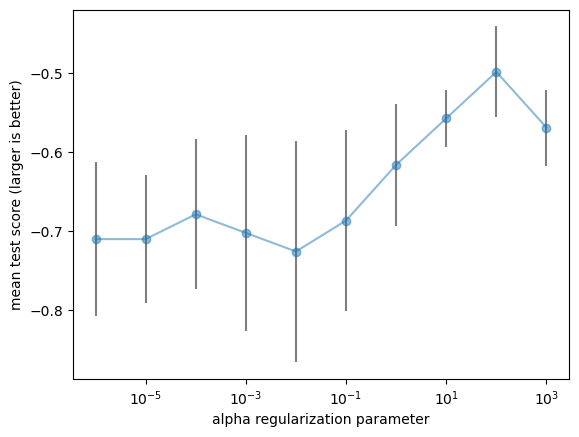

In [23]:
# regularization parameter picked by CV
print(f">> Grid Search best params : {grid_cv.best_params_}")

plt.errorbar(alphas, grid_cv.cv_results_["mean_test_score"],
             grid_cv.cv_results_["std_test_score"], fmt='-o', ecolor="black", alpha=0.5)
plt.xscale('log')
plt.xlabel("alpha regularization parameter")
plt.ylabel("mean test score (larger is better)");

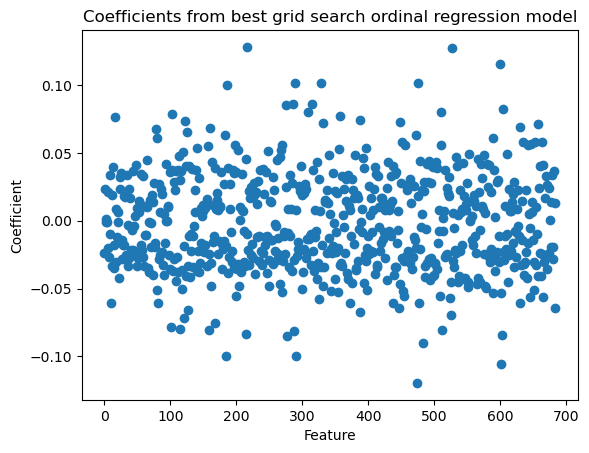

In [24]:
# Now fit the model with the best parameter to the entire dataset
best_model = grid_cv.best_estimator_
best_alpha = best_model.get_params()['model__alpha']

best_model.fit(X, y)
best_coefs = grid_cv.best_estimator_['model'].coef_

plt.plot(best_coefs, 'o')
plt.title("Coefficients from best grid search ordinal regression model")
plt.xlabel("Feature")
plt.ylabel("Coefficient");

In [25]:
# Find feature names after the variance threshold
vt = grid_cv.best_estimator_.named_steps['vt']
feature_names_after_threshold = enc.get_feature_names_out()[vt.get_support()]

best_results = pd.DataFrame({'feature':feature_names_after_threshold, 'coef':best_coefs})
# extract the Residue index and the AA mutation 
best_results[["idx", "aa_mut"]] = \
    best_results.feature.str.extractall(r"x([0-9]+)_([A-Z])").reset_index(drop=True)
best_results["idx"] = best_results.idx.astype(int)


best_results["aa_wt"] = pd.Series([WT_str[i] for i in best_results.idx])

# offset for zero based indexing and also for skipping the start codon
best_results["parent_idx"] = best_results.idx + 2 
# use parent idx to write out feature name
best_results["fname"] = best_results.aa_wt + \
                best_results.parent_idx.astype(str) + best_results.aa_mut
# mark feature name if the residue is a "benefial" residue
best_results["ftype"] = ""
best_results.loc[best_results.parent_idx.isin(beneficial_parent_indices),
                "ftype"] = "beneficial_residue"

# count the number of observations of this feature
best_results["N_obs"] = X.sum(axis=0)[vt.get_support()].astype(int)

# count the number of observations in each response category for a feature
for response, category in response_category_dict.items():
    best_results["N_obs_" + category.split()[0]] = \
            X[y == response, :].sum(axis=0).astype(int)[vt.get_support()]

In [26]:
pipeline.fit(X,y)
def mytransform(X):
    return pipeline.named_steps['scaler'].transform(pipeline.named_steps['vt'].transform(X))
Xinp = mytransform(X)

### Run Ordinal Regression with small regularization value

The best regularization parameter does not predict any sequences in bin 3 so we run ordinal regression again with a small regularization value and ignore the GridSearch above.


In [27]:
import mord_sol
model = mord_sol.LogisticAT(alpha=0.01)

model.fit(Xinp, y) # Xinp is the dataset after transformation

# The score is negative of mean absolute error between prediction and response vector
# this is way better than the grid search becuase it is insample and not insample/outsample scoring
print(f"Model Score with alpha={model.alpha} : {model.score(Xinp, y):.2f}")

Model Score with alpha=0.01 : -0.03


In [28]:
# replace the coefs in the best_results dataframe with the coefs of this new model. 
best_results.coef = model.coef_

/tmp/ipykernel_1496/3098384432.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  fig = sns.heatmap(best_results.pivot("aa_mut", "parent_idx", "coef"),


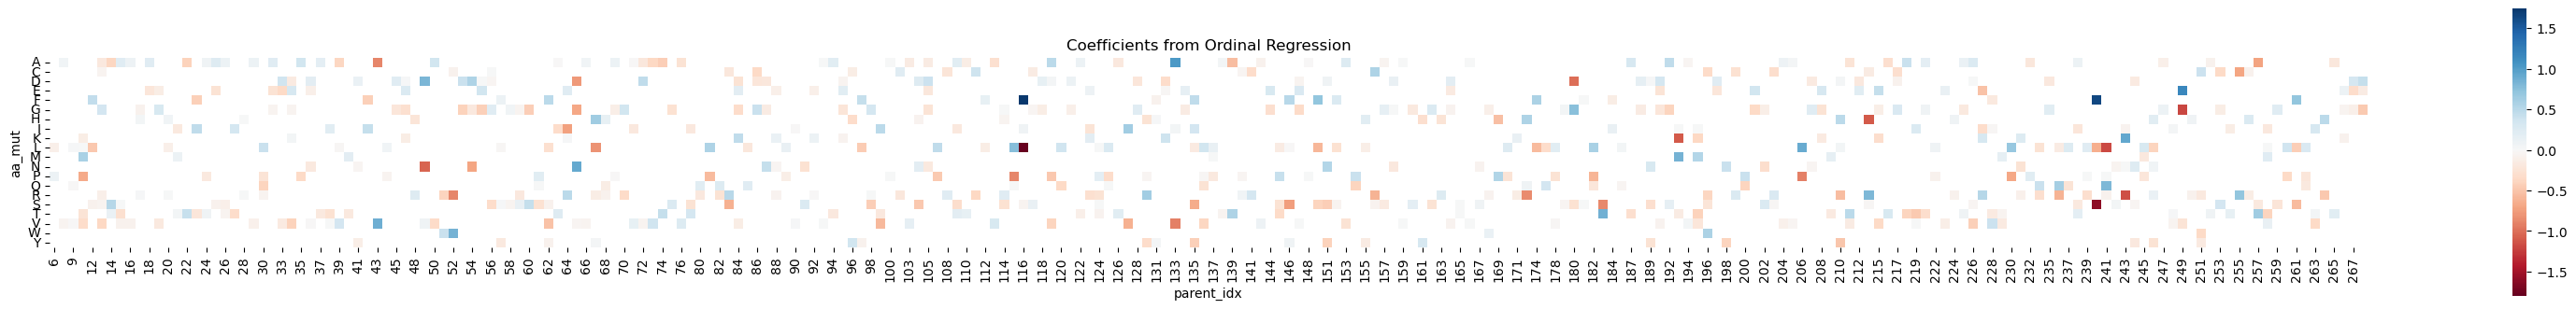

In [29]:
plt.figure(figsize=(40,4))
fig = sns.heatmap(best_results.pivot("aa_mut", "parent_idx", "coef"), 
                  center = 0, cmap = 'RdBu', square = True)
plt.title("Coefficients from Ordinal Regression")
# do not save as we are using the score of 1 mutants instead
#plt.savefig(f"../output/2D/{activity_type}_coef_heatmap.png", dpi=500, facecolor='w', transparent=False)
pass

In [30]:
WT_one_hot = enc.transform([list(WT_str),])
WT_transform = mytransform(WT_one_hot)
WT_score = WT_transform @ model.coef_

In [31]:
WT_probs = model.predict_proba(WT_transform)
WT_predicted_repsonse = WT_probs.argmax()
with np.printoptions(precision=3, suppress=True):
    print(f"Parent probability vector: {WT_probs}")
print(f"Parent predicted Response code: {WT_predicted_repsonse}")

Parent probability vector: [[0.    0.022 0.718 0.259]]
Parent predicted Response code: 2


In [32]:
# Using the model to score each sequence that went into it.

# Note, we have to use Xinp instead of X
seq_scores = np.einsum("bi,i->b", Xinp, model.coef_) - WT_score

df_model_scores = df_model_seqs[["mutants_in_seq", "category"]].copy()
df_model_scores["predicted_response"] = model.predict_proba(Xinp).argmax(1)
df_model_scores["predicted_category"] = df_model_scores["predicted_response"].map(
                                                response_category_dict)
del df_model_scores["predicted_response"]
df_model_scores["seq_scores"] = seq_scores

In [33]:
AAs = 'ACDEFGHIKLMNPQRSTVWY'

def mut_wt(idx, aa):
    mut = WT_str[:idx] + aa + WT_str[(idx+1):]
    return mut

# Create a single mutant for each wildType

# use python indexing (idx) here and not parent_idx
seqs = pd.Series([mut_wt(row['idx'], row['aa_mut']) for idx, row in best_results.iterrows()])
mut_cols = seqs.apply(lambda x: pd.Series(list(x)))
mut_transform = mytransform(enc.transform(mut_cols))

mut_score = mut_transform @ model.coef_ - WT_score

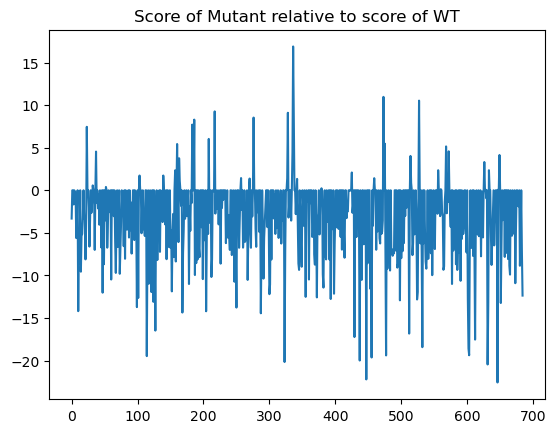

In [34]:
plt.plot(mut_score)
plt.title("Score of Mutant relative to score of WT");

/tmp/ipykernel_1496/4185911808.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  fig = sns.heatmap(best_results.pivot("aa_mut", "parent_idx", "score_vs_wt"),


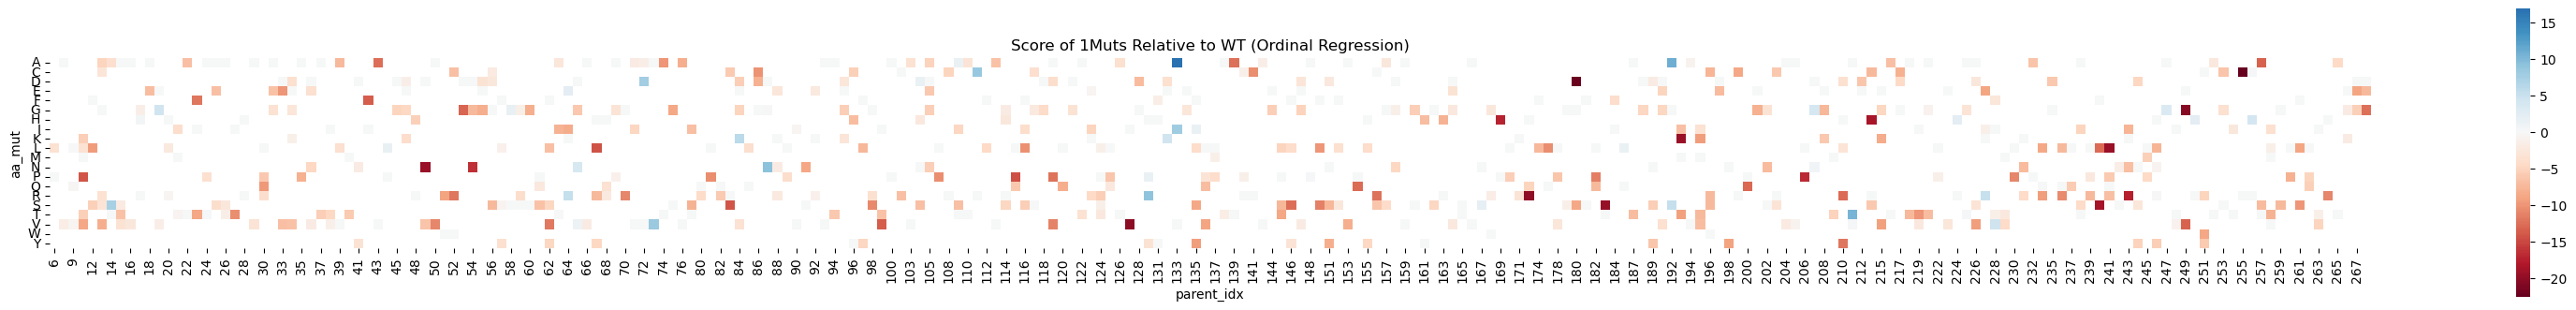

In [35]:
best_results["score_vs_wt"] = mut_score
plt.figure(figsize=(40,4))
fig = sns.heatmap(best_results.pivot("aa_mut", "parent_idx", "score_vs_wt"), 
                  center = 0, cmap = 'RdBu', square = True)
plt.title("Score of 1Muts Relative to WT (Ordinal Regression)");
plt.savefig(f"../output/2D/{activity_type}_score_heatmap.png", dpi=500, facecolor='w', transparent=False)
pass

In [36]:
# The sovler contains the inverse hessian
# So we can use it to calculate the variance-covariance matrix and the standard errors
# See https://stats.stackexchange.com/a/68095 for details
se = np.sqrt(np.diag(model.sol["hess_inv"].todense()))

In [37]:
best_results["se"] = se[:Xinp.shape[1]]
best_results["zval"] = (best_results.coef / best_results.se)
best_results["pval"] = (1 - scipy.stats.norm.cdf(best_results.zval.abs())) * 2

In [44]:
# Now limit to mutants that are not WT
best_results_no_wt = best_results[best_results.aa_mut != best_results.aa_wt]

descending_sort_results = best_results_no_wt.sort_values('score_vs_wt', ascending=False)[[
    "fname", "parent_idx", "aa_mut", "aa_wt", "N_obs", 
    'N_obs_High', 'N_obs_Parent', 'N_obs_Low', 'N_obs_No',
    "score_vs_wt", "pval", "se","ftype"]]
descending_sort_results.head(10)

,fname,parent_idx,aa_mut,aa_wt,N_obs,N_obs_High,N_obs_Parent,N_obs_Low,N_obs_No,score_vs_wt,pval,se,ftype
336,V133A,133,A,V,3,0,0,1,2,16.889352,0.366843,1.138955,
473,G192A,192,A,G,1,1,0,0,0,10.972073,0.666103,1.058005,
527,A211T,211,T,A,1,1,0,0,0,10.529735,0.734905,1.440236,
217,D87N,87,N,D,1,1,0,0,0,9.265140,0.782618,1.580460,
328,H129R,129,R,H,2,1,0,0,1,9.103676,0.757015,2.008643,
276,R111C,111,C,R,2,1,0,0,1,8.540292,0.726452,1.076706,
186,A73V,73,V,A,2,1,0,1,0,8.298093,0.711753,0.990526,
337,V133I,133,I,V,1,0,0,1,0,8.068021,0.965984,1.041567,
183,V72D,72,D,V,1,1,0,0,0,7.714079,0.666103,1.058005,
23,T14S,14,S,T,1,0,0,1,0,7.453864,0.619799,1.038314,


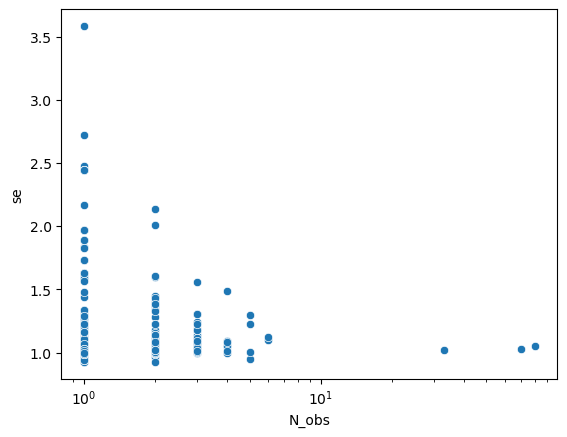

In [55]:
import seaborn as sns

sns.scatterplot(data=descending_sort_results, x="N_obs", y="se")
plt.xscale('log')

In [39]:
# write out to excel

model_results_excel_filename = f"{output_dir}/{activity_type}_model_results.xlsx"


with pd.ExcelWriter(model_results_excel_filename, mode='w') as writer:

    descending_sort_results.to_excel(
        writer, index=False, sheet_name="feature_scores")
    
    df_model_scores.sort_values("seq_scores", ascending=False).to_excel(
        writer, sheet_name='seq_scores', index=False)

In [40]:
descending_sort_results[descending_sort_results.parent_idx == 152]

,fname,parent_idx,aa_mut,aa_wt,N_obs,N_obs_High,N_obs_Parent,N_obs_Low,N_obs_No,score_vs_wt,pval,ftype
389,F152S,152,S,F,1,0,0,1,0,-2.595035,0.958637,beneficial_residue
388,F152L,152,L,F,5,2,0,1,2,-3.702664,0.776474,beneficial_residue


In [41]:
# import plotly.express as px

# fig = px.scatter(best_results_no_wt, x="score_vs_wt", y="pval", color="N_obs", hover_name="fname",
#                  title="Score of 1 mutants relative to WT (Ordinal Regression)", 
#                  log_y=True,
#                  color_continuous_scale="BlueRed",
#                  hover_data=["score_vs_wt", "pval", "N_obs"], # makes notebook large
#                  labels={
#                      "pval": "p value (log scale)",
#                      "score_vs_wt": "Score of 1 Mutant vs WildType"
#                  })
# fig.update_layout(yaxis_autorange="reversed")


# fig.show() # only works interactively 
# fig.write_html(f"../output/2D/{activity_type}_score_vs_pval.html") # So we also write it out to html

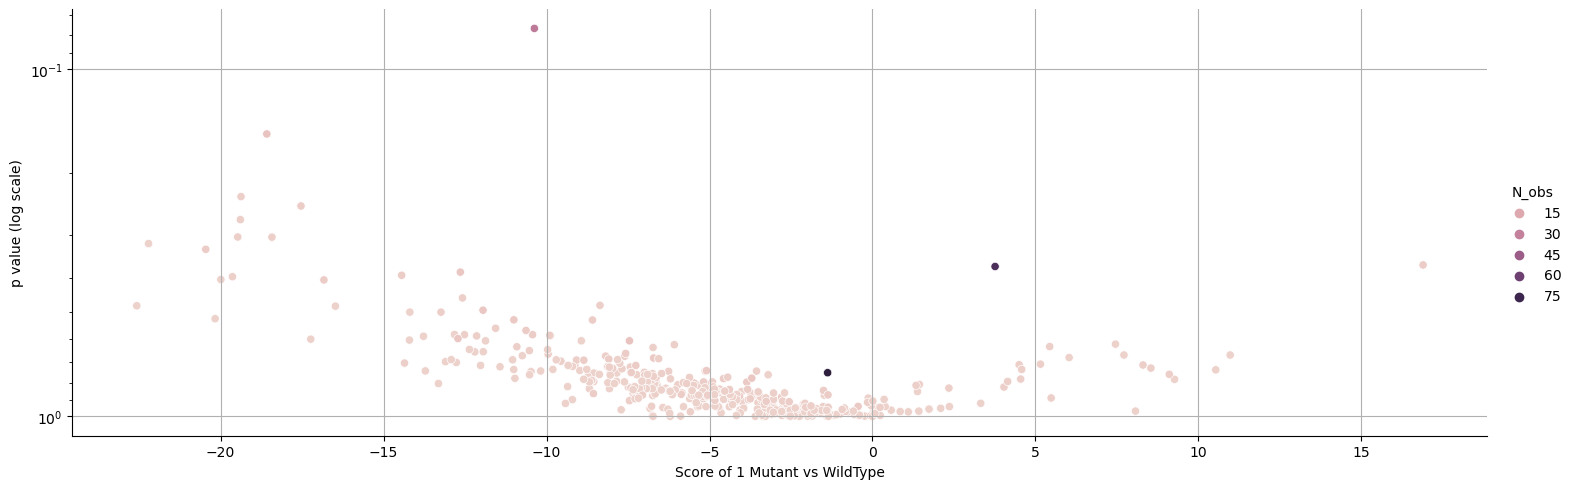

In [42]:
s = sns.relplot(data=best_results_no_wt, x="score_vs_wt", y="pval", hue="N_obs", kind="scatter", aspect=3)
ax = next(s.axes.flat)

ax.set_yscale('log')
ax.invert_yaxis()
ax.set_ylabel("p value (log scale)")
ax.set_xlabel("Score of 1 Mutant vs WildType")
ax.grid()
pass

In [43]:
# look at all sequences with response code 3
mut_cols = df_model_seqs[df_model_seqs.response == 3].sequence_aa.apply(lambda x: pd.Series(list(x[1:-1])))
mut_transform = mytransform(enc.transform(mut_cols))
mut_probs = model.predict_proba(mut_transform)

predicted_response = mut_probs.argmax(axis=1)
print("Predicted response. ", predicted_response)

Predicted response.  [3 3 2 3 2 3 2 3 2 3 3]
